In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
df=pd.read_csv(r"../../dataset/restaurant.csv")
df=df.dropna(subset=["Cuisines"])
df.isnull().sum()
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.select_dtypes(include=["int64","float64"]).columns

Index(['Restaurant ID', 'Country Code', 'Longitude', 'Latitude',
       'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')

In [5]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.542000e+03,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000
mean,9.043301e+06,18.179208,64.274997,25.848532,1200.326137,1.804968,2.665238,156.772060
std,8.791967e+06,56.451600,41.197602,11.010094,16128.743876,0.905563,1.516588,430.203324
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019312e+05,1.000000,77.081565,28.478658,250.000000,1.000000,2.500000,5.000000
50%,6.002726e+06,1.000000,77.192031,28.570444,400.000000,2.000000,3.200000,31.000000
75%,1.835260e+07,1.000000,77.282043,28.642711,700.000000,2.000000,3.700000,130.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [6]:
numerical_columns=["Aggregate rating","Average Cost for two","Votes","Price range"]
for col in numerical_columns:
    print(f"\n{col}")
    print(f"mean:{df[col].mean():.2f}")
    print(f"median:{df[col].median():.2f}")
    print(f"std:{df[col].std():.2f}")


Aggregate rating
mean:2.67
median:3.20
std:1.52

Average Cost for two
mean:1200.33
median:400.00
std:16128.74

Votes
mean:156.77
median:31.00
std:430.20

Price range
mean:1.80
median:2.00
std:0.91


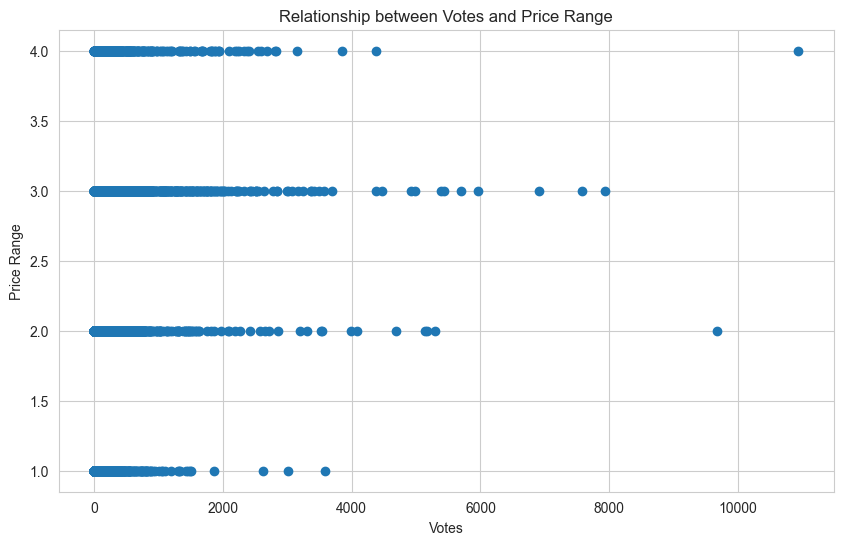

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Votes"], df["Price range"])
plt.xlabel('Votes')
plt.ylabel('Price Range')
plt.title('Relationship between Votes and Price Range')
plt.show()

In [31]:
Categorical_columns=["Country Code","City","Cuisines"]
for col in Categorical_columns:
    
    print(f"\n{df[col].value_counts().head(20)}")


Country Code
1      8652
216     425
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64

City
New Delhi          5473
Gurgaon            1118
Noida              1080
Faridabad           251
Ghaziabad            25
Bhubaneshwar         21
Ahmedabad            21
Lucknow              21
Guwahati             21
Amritsar             21
S��o Paulo           20
Bras�_lia            20
Doha                 20
Cape Town            20
Wellington City      20
Auckland             20
Mumbai               20
Mangalore            20
Ludhiana             20
Nashik               20
Name: count, dtype: int64

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                        

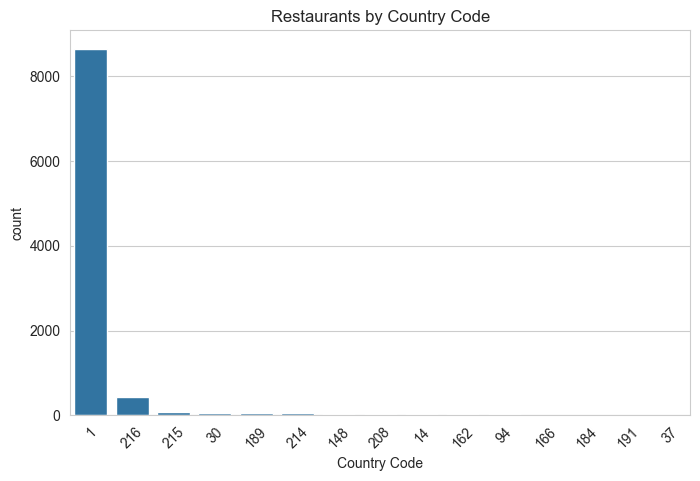

In [52]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Country Code",
    order=df["Country Code"].value_counts().index
)
plt.title("Restaurants by Country Code")
plt.xticks(rotation=45)
plt.show()

In [62]:
print("Top ten cities with more number of resturants")
top_cities=df["City"].value_counts().head(10)
print(top_cities)

Top ten cities with more number of resturants
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


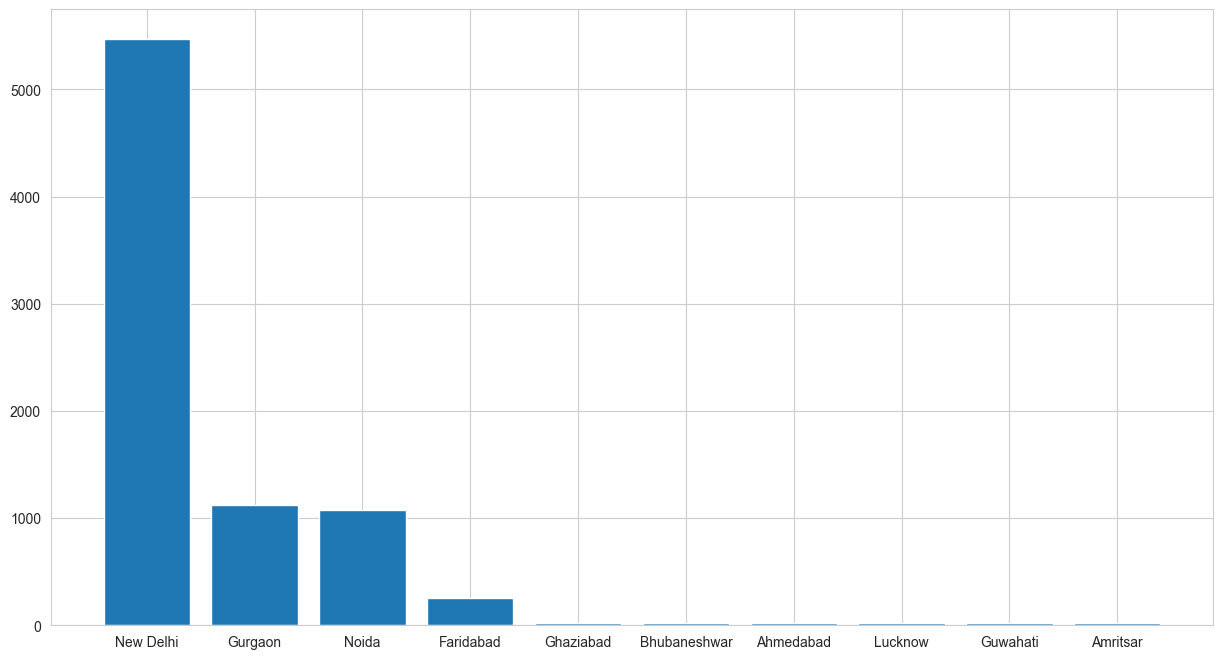

In [118]:
plt.figure(figsize=(15,8))
plt.bar(top_cities.index,top_cities.values)
plt.xticks(rotation=0)
plt.show()

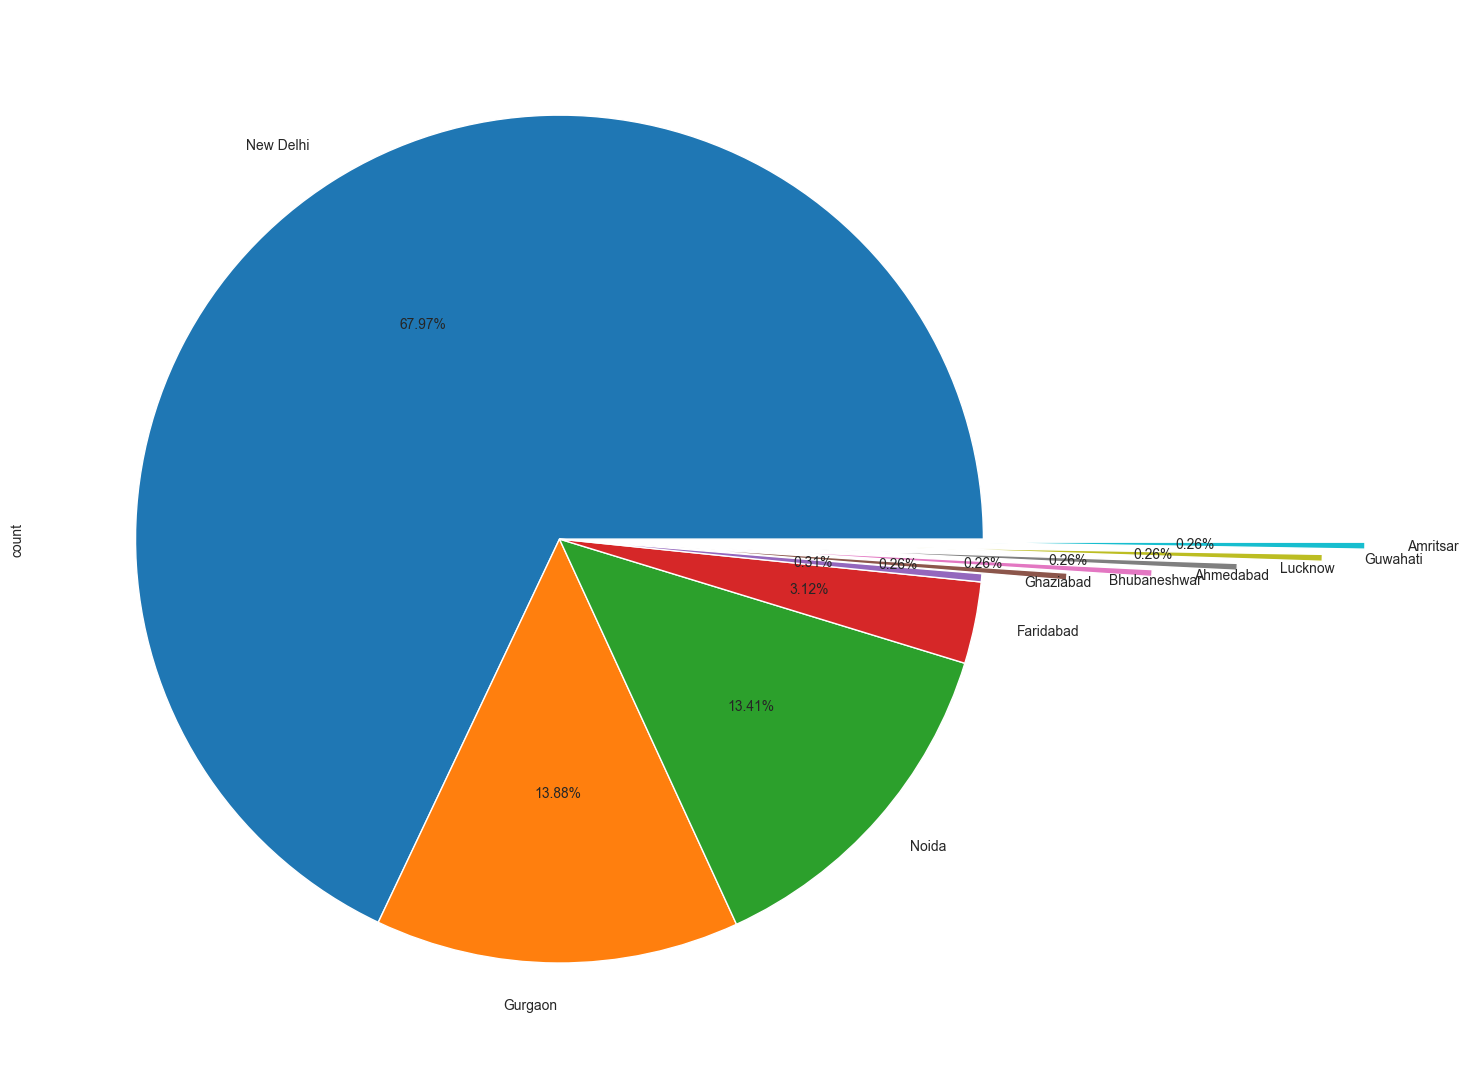

In [120]:
explode=[.0,.0,.0,.0,.0,.2,.4,.6,.8,.9]
top_cities.plot(kind='pie',explode=explode,autopct="%.2f%%",figsize=(15,15))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Cuisines
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


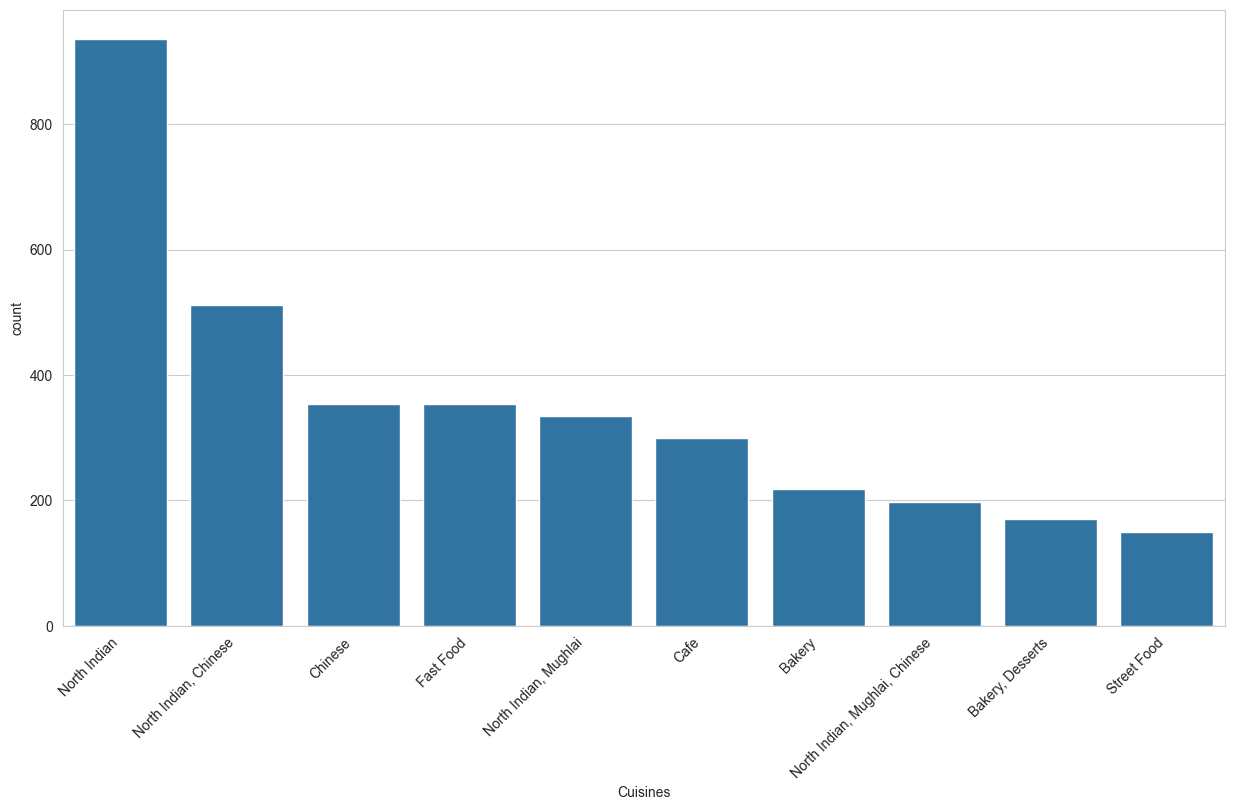

In [133]:
top_Cuisines=df["Cuisines"].value_counts().head(10)
print("Top 10 Cuisines")
print(top_Cuisines)
plt.figure(figsize=(15,8))
sns.countplot(
    data=df,
    x="Cuisines",
    order=df["Cuisines"].value_counts().head(10).index
)
plt.xticks(rotation=45,ha='right')
plt.show()

In [14]:
## Business Insights
#-> The dataset contains resturants from multiple countries, but the majority of the resturants belongs to "india"
#-> The cities which contains most of the  resturants are "New Delhi","Gurgaon","Noida",
#-> The cuisines that are most severed are "North Indian","Chinese","Fast Food"